In [1]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import imdb
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np 
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

In [2]:
nb_words_total = 20000
(X_train_data, Y_train), (X_test_data, Y_test) =imdb.load_data(num_words = nb_words_total )

In [3]:
 print((X_train_data[123]))

[1, 307, 5, 1301, 20, 1026, 2511, 87, 2775, 52, 116, 5, 31, 7, 4, 91, 1220, 102, 13, 28, 110, 11, 6, 137, 13, 115, 219, 141, 35, 221, 956, 54, 13, 16, 11, 2714, 61, 322, 423, 12, 38, 76, 59, 1803, 72, 8, 10508, 23, 5, 967, 12, 38, 85, 62, 358, 99]


In [4]:
print(len(X_train_data[12]))
#index_mots = imdb.get_word_index()


117


In [5]:
def affiche_texte(num):
    index_words = imdb.get_word_index()
    index_words_inverse = dict([(value, key)
                                for (key, value) in index_words.items()])
    critic_words = ' '.join([index_words_inverse.get(i-3,"")
                                for i in X_train_data[num]])
    print("review :\n", critic_words)
    print("Note 0 (négative) ou 1 (positive) ? :", Y_train[num])
    print("review  :\n", X_train_data[num])
    print(len(X_train_data[num]))
    #print( index_words_inverse)
    
    return
    
affiche_texte(123) 


review :
  beautiful and touching movie rich colors great settings good acting and one of the most charming movies i have seen in a while i never saw such an interesting setting when i was in china my wife liked it so much she asked me to log on and rate it so other would enjoy too
Note 0 (négative) ou 1 (positive) ? : 1
review  :
 [1, 307, 5, 1301, 20, 1026, 2511, 87, 2775, 52, 116, 5, 31, 7, 4, 91, 1220, 102, 13, 28, 110, 11, 6, 137, 13, 115, 219, 141, 35, 221, 956, 54, 13, 16, 11, 2714, 61, 322, 423, 12, 38, 76, 59, 1803, 72, 8, 10508, 23, 5, 967, 12, 38, 85, 62, 358, 99]
56


In [6]:
def vectorization_critic(X_data):
    vectors = np.zeros((len(X_data), nb_words_total))
    for i in range(len(X_data)):
        for c in X_data[i]:
            vectors[i,c] = 1.0
    return vectors

X_train = vectorization_critic(X_train_data)
X_test = vectorization_critic(X_test_data)
print((X_train[12]))

[0. 1. 0. ... 0. 0. 0.]


In [7]:
modele = Sequential()
p = 5
modele.add(Dense(p, input_dim=nb_words_total, activation='relu'))
modele.add(Dense(p, activation='relu'))
modele.add(Dense(p, activation='relu'))
modele.add(Dense(1, activation='sigmoid'))
modele.compile(loss='binary_crossentropy',
optimizer='sgd',
metrics=['accuracy'])

In [8]:

history= modele.fit (X_train, Y_train, batch_size=150, epochs=50, validation_split=0.2)

modele.evaluate(X_test, Y_test)

Epoch 1/50
134/134 [==============================] - 11s 52ms/step - loss: 0.6912 - accuracy: 0.5461 - val_loss: 0.6865 - val_accuracy: 0.6204
Epoch 2/50
134/134 [==============================] - 2s 17ms/step - loss: 0.6702 - accuracy: 0.6860 - val_loss: 0.6460 - val_accuracy: 0.7492
Epoch 3/50
134/134 [==============================] - 2s 16ms/step - loss: 0.6135 - accuracy: 0.7831 - val_loss: 0.5739 - val_accuracy: 0.8010
Epoch 4/50
134/134 [==============================] - 2s 16ms/step - loss: 0.5259 - accuracy: 0.8273 - val_loss: 0.4824 - val_accuracy: 0.8352
Epoch 5/50
134/134 [==============================] - 2s 17ms/step - loss: 0.4322 - accuracy: 0.8501 - val_loss: 0.4043 - val_accuracy: 0.8494
Epoch 6/50
134/134 [==============================] - 2s 17ms/step - loss: 0.3647 - accuracy: 0.8644 - val_loss: 0.3600 - val_accuracy: 0.8568
Epoch 7/50
134/134 [==============================] - 2s 17ms/step - loss: 0.3216 - accuracy: 0.8757 - val_loss: 0.3338 - val_accuracy: 0.864

[0.48645082116127014, 0.8621199727058411]

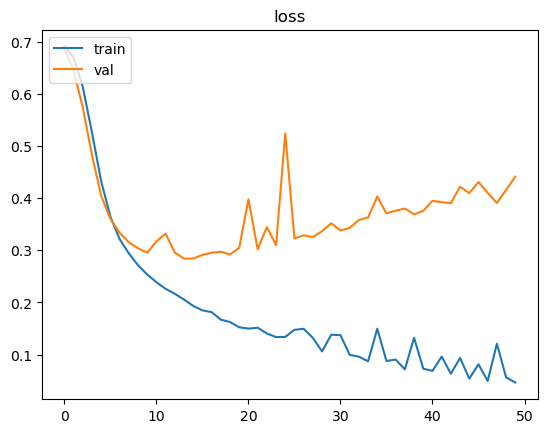

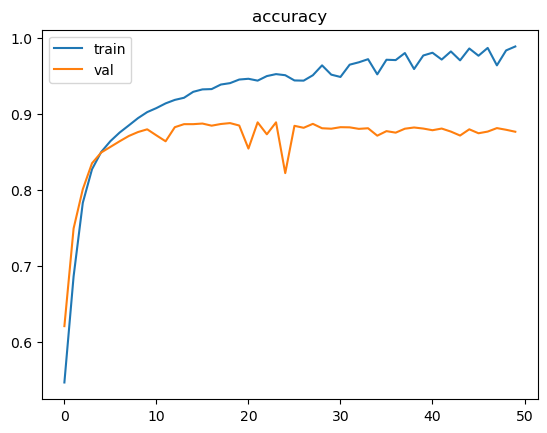

In [9]:
loss_curve = history.history["loss"]
acc_curve = history.history["accuracy"]

loss_val_curve = history.history["val_loss"]
 
acc_val_curve = history.history["val_accuracy"]

plt.plot(loss_curve,label="train")
    
plt.plot(loss_val_curve,label="val")
plt.legend(loc="upper left")
plt.title("loss")
plt.show()
plt.plot(acc_curve,label="train")
plt.plot(acc_val_curve,label="val")
plt.legend(loc="upper left")
plt.title("accuracy")
plt.show()

In [10]:
print("Critique la plus longue :", max(len(x) for x in X_train_data), "mots")
print("Critique la plus courte :", min(len(x) for x in X_train_data), "mots")

Critique la plus longue : 2494 mots
Critique la plus courte : 11 mots
